<a href="https://colab.research.google.com/github/DCC-Lab/STUAART/blob/master/Correct_mass_time_series_for_baseline_shift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Correct mass time series for baseline shift


This colab takes all data of one cage (after buffer flushes) and correct for baseline drifts. Over time, the tare is not at 0 g anymore. This Colab puts the tare back to 0 g.

Before running this script, copy and paste your data on your google drive at a location the you know.

**Premilinary step:**
At your first run of the day, uncomment the following cell and run it. Then, comment it and restart the session. The rest of the script should run smoothly after this step.

In [ ]:
# !pip install ipympl -q

In [ ]:
!pip install ipympl -q

from google.colab import output
output.enable_custom_widget_manager()

%matplotlib widget

import numpy as np
import pandas as pd
import os
import shutil
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector, Button
from sklearn.mixture import GaussianMixture
from scipy.stats import norm, gaussian_kde
from scipy.signal import find_peaks
from sklearn.cluster import DBSCAN
from tqdm import tqdm
import gc
import threading

## Step 1 : Define variables and mount the drive

In the first cell, you must define some variables:
 - You must change `project_directory` and `folder_data_of_all_experiment_path` to where all the .csv data from one cage is saved in your Google drive.
 - `sampling_frequency` defines the sampling frequency at which the mass data is acquired and saved. It should be either 10 Hz of 80 Hz.
 - If `debug_mode` is True, it prints more informations for the user
 - `file_size_treshold` is used to define the treshold at which a file is considered heavy. If a file in the folder at path `file_data_of_all_experiment_path` goes over this treshold, a local copy of the file is created at *content/temp_csv_data*, a local instance storage, before reading the data in the file. This folder is virtually instantaneous and should not time out.
 - If `outlier_removal` is True, the resultant data will be rid of outliers.
 - `baseline_correction_algorithm` defines the algorithm to use to find the baseline in the individual mass time series. This variable is either equal to **GMM**, **KDE**, **DBSCAN** or **Rolling Mean** for baseline correction. If this variable is equal to `None`, no baseline correction will be performed on the mass time series. The users are free to try any of the algorithms to correct for baseline drifts.
 - `bin_size` defines the time, in hours, of the sliding analysis windows used to segment the continuous time series for baseline correction. Default is 1.0.

For better results on the baseline correction, it is suggested to remove outliers, therefore for `outlier_removal` to be True.

Using **Rolling Mean** for very stable raw mass time series is recommended.

Nothing in the second cell should be changed.
- To access the data on your Google drive, it must be mounted. When you first run the script, you must follow the steps and accept access to your drive.
- After defining the path variables and mounting the drive, the mass time series are accessed.

In [ ]:
# Change these variables
project_directory = "/content/drive/My Drive/DCCM_Lab/labdata/vpineaunoel/stuaart"
folder_data_of_all_experiment_path = project_directory + "/20260730-3MiceInSTUAARTs_5/Red/WithoutBufferFlushes/"
sampling_frequency = 80
debug_mode = False
file_size_threshold = 200 * 1024 * 1024
outlier_removal = True # if False, the outliers are not removed from the mass time series
baseline_correction_algorithm  = "DBSCAN" # is either None, GMM, KDE, DBSCAN or Rolling Mean
manual_baseline_correction = True # is either True or False according to if the user wants to corrects manually the baseline before saving
bin_size = 1.0

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
import os
os.chdir(project_directory)
local_temp_folder = "/content/temp_csv_data"

Mounted at /content/drive/


## Step 2 : Define functions

The tare (baseline) shifts over time. This step is to readjust the baseline to 0 g.

* `create_temporary_local_folder()` : Used if files are too heavy to prevent RAM crashes.

* `remove_outliers()` : Outliers can be removed if `outlier_removal` is `True`. The data points in the mass time series that have a value that is too far from its neighboring data points are replaced by `np.nan`.

* `smooth_mass_data()` : Mass time series are individually smoothened lightly with a rolling median before baseline correction. This is done if `baseline_correction_algorithm` is not `None`.

* `find_offset()` and `find_baseline_rolling_mean()` :

  Chronologically tracks the slow mechanical drift of the empty cage while ignoring the sudden mass spikes caused by the presence of a mouse.
  - Calculates the starting baseline of the scale with `find_offset()`.
  - Over a time window (defined by the sampling frequency as `n_values`), look at each data point to cluster it as part of the baseline or part of the animal's mass from a fixed threshold.
  - `NaN` elements are ignored.
  - If the mass is under the threshold (indicating the scale is likely empty), it looks backward at the recent historical window (`n_values`) and calculates the average.
  - If that recent average hasn't drifted too far from the current offset, the algorithm officially updates the baseline memory to track the new physical drift.

* `classify_baseline_gmm()` :

  Gaussian Mixture Models (GMMs) are used to find the densest mass clusters per `bin_size` (in hour).
  - For each time bin corresponding to the `bin_size`, the algorithm fits two separate Gaussian models to the data: a unimodal and a bimodal model. The Bayesian Information Criterion (BIC) score is calculated to determine which model statistically fits the distribution of the data within the current bin better.
  - If the data better fits a unimodal model, it checks if that peak is massively higher than the memory (`mouse_presence_threshold`).
    - If so, it assumes a mouse is sleeping on the scale and freezes the memory.
    - Otherwise, it accepts it as the baseline and updates the memory.
  - If the data better fits a bimodal model, the algorithm sorts the 2 detected peaks. Because the mouse can only add weight, it identifies the lowest Gaussian median as the empty cage baseline.
    - The new baseline is compared to the `max_drift_allowed` threshold. If the drift is extreme, it rejects the GMM's median baseline value and anchors to the baseline memory.
    - Otherwise, it extracts the median mass of that specific baseline cluster and maps it directly to the corresponding timestamps.
  - The baseline data points are interpolated.
  - A rolling mean smoothens the baseline array.

* `classify_baseline_kde()` :

  Kernel Density Estimations (KDEs) are used to smoothly find the most frequent mass peaks.
  - For each time bin corresponding to the `bin_size`, the algorithm fits a continuous probability curve (a KDE) over the data. It then scans the curve for prominent peaks, actively ignoring tiny micro-bumps (anything under 5% prominence), and sorts the valid peaks by density.
  - If the KDE curve only has one valid peak (unimodal), the algorithm checks the difference between this peak and the established memory (`mouse_presence_threshold`).
    - If the difference between the detected peak and the previous baseline value is greater than `mouse_presence_threshold`, it rejects the peak, and freezes the memory.
    - Otherwise, it updates the memory.
  - If the curve has two or more peaks, the algorithm grabs the two densest ones (bimodal). Because a mouse can only add weight to the system, it identifies the lowest mass peak as the empty cage and the higher mass peak as the mouse.
  - Note on current logic: The provided script currently includes a strict drift check : if any previous baseline memory exists, it freezes the baseline to hold that memory.
  - The baseline data points are interpolated.
  - A rolling mean smoothens the baseline array.

* `classify_baseline_dbscan()` :

  Density-Based Spatial Clustering of Applications with Noise (DBSCAN) is used to group the densest mass readings into distinct clusters while filtering out transitional noise.
  - For each time bin corresponding to the `bin_size`, the algorithm decimates the data to optimize memory, applies DBSCAN clustering to find distinct mass states, and calculates the median mass for each valid cluster.
  - The algorithm evaluates the mass difference between the two largest clusters. - If the distance is >= `mouse_presence_threshold`, it confirms a true cage-and-mouse state (true bimodal). If they are closer than the threshold, it merges them into a single state (unimodal).
  - If True Bimodal: Because a mouse can only add weight, it identifies the lower cluster as the empty cage and the higher cluster as the mouse. It maps the baseline and updates the memory.
  - If Unimodal: It checks the difference between the single cluster and the established memory.
    - If the sudden increase in mass is greater than `mouse_presence_threshold`, it rejects the cluster and assigns `NaN`. The label of the detected peak is uncertain.
    - Otherwise, it accepts the cluster as the empty cage and updates the memory.
  - The baseline data points are interpolated to bridge the `NaN` gaps.
  - A rolling mean smoothens the baseline array.

* `STUAART_GUI()` :  

  The STUAART_GUI is built on top of Matplotlib's interactive event-handling backend. It provides a visual interface to inspect raw mass time series, one scale at a time, one day at a time. The user can see the automated baseline estimations, and resulting corrected animal masses on top of the raw mass time series. Files are automatically exported to CSV in a background thread the moment all scales from one day are reviewed.

In [ ]:
def create_temporary_local_folder(local_temp_folder = "/content/temp_csv_data"):
  """
  Create a temporary local folder for the heavy files
  """
  os.makedirs(local_temp_folder, exist_ok=True)


def remove_outliers(data, window_size=30, delta_threshold=25):
  """
  Removes local outliers from a 2D time series by comparing against a rolling median.
  - data: numpy array of shape (number of timestamps, number of scales)
  - window_size: integer (number of timestamps to look at simultaneously. Use an odd number).
  - delta_threshold: float (maximum allowed difference from the local median).
  """
  # Convert input data into dataframe for cleaner reading of the script
  df = pd.DataFrame(data)

  # Calculate the rolling median across the rows (timestamps) for each column independently.
  rolling_median = df.rolling(window=int(window_size), center=True, min_periods=1).median()

  # Calculate how far each point deviates from its local baseline
  deviation = np.abs(df - rolling_median)

  # Keep the original data if the deviation is below your delta threshold
  # Otherwise, replace the outlier with np.nan.
  cleaned_data = np.where(deviation < delta_threshold, data, np.nan)

  return cleaned_data


def subtract_baseline(data_of_scale, baseline):
  """
  Subtract the baseline to the mass time series.
  """
  data_of_scale = data_of_scale - baseline
  return data_of_scale


def get_cumulative_time(time):
  """
  From an array of timestamps in float, produces an array of cumulative time in hours.
  """
  cumulative_time = time.copy()

  # Find everywhere the time drops backward (e.g., crosses midnight from 23.99 to 0.00)
  time_diff = np.diff(cumulative_time)
  reset_indices = np.where(time_diff < -12.0)[0]

  # Add 24 hours to all data points that happen after each midnight crossover
  for idx in reset_indices:
    cumulative_time[idx + 1:] += 24.0

  return cumulative_time


def smooth_mass_data(time_vector, data_of_scale, time_unit='h', window_size='2s'):
  """
  Applies a time-aware rolling median to remove high-frequency sensor noise.
  Includes safeguards to handle NaNs and out-of-order timestamps without
  changing the final array length.
  """
  # Create a DataFrame and track the exact original array indices
  df = pd.DataFrame({'time': pd.to_timedelta(time_vector, unit=time_unit), 'mass': data_of_scale, 'original_order': range(len(time_vector))})

  # Isolate only the rows with valid timestamps to prevent the monotonic error
  valid_time_df = df.dropna(subset=['time']).copy()

  # Force the index to be perfectly chronological (monotonic)
  valid_time_df = valid_time_df.sort_values('time')
  valid_time_df.set_index('time', inplace=True)

  # Apply the time-aware rolling median
  valid_time_df['smoothed_mass'] = valid_time_df['mass'].rolling(window=window_size, min_periods=1).median()

  # Reset the index and sort back to the exact original hardware order
  valid_time_df = valid_time_df.reset_index().sort_values('original_order')

  # Safely merge the smoothed data back into the original array shape
  df['smoothed_mass'] = np.nan
  df.loc[valid_time_df['original_order'], 'smoothed_mass'] = valid_time_df['smoothed_mass'].values

  return df['smoothed_mass'].to_numpy()


def find_offset(data_of_scale, tolerance: float=2):
  """
  This function can be used to calculate the first offset of the signal. The code
  goes trough the signal and verifies if it is stable. Stability is
  established using a mass tolerance (default is 0.2g). When the signal goes beyond this variation,
  the previous values are averaged to calculate the initial offset.

  Arguments:
  - tolerance: range of mass around previous value considered as stable. default is 0.2g
  """
  # declare list to store old values to average for calculation of offset
  offset_values = [data_of_scale[0]]
  # store previous value. first previous value is the value at first time tick
  last_value = data_of_scale[0]

  for value in data_of_scale[1:]:
    # verify if difference between to consecutive values is less than tolerance
    if np.abs(value - last_value) > tolerance:
      # break loop when stability criteria is not met
      break
    # append value to list if stability criteria is met
    offset_values.append(value)

    # reassign last_value to current value for next iteration
    last_value = value

  # return mean of stable values
  return np.nanmean(np.array(offset_values))


def find_baseline_rolling_mean(time, data_of_scale, sampling_frequency, threshold: float=2):
  """
  This function goes through the mass values to identify the drifting baseline of the signal.
  Baseline is associated to an array containing the offset at each time tick.
  The stability is verified by looking at n_values in the past from current time increment and looking if they are over a threshold.

  Arguments:
  -
  - sampling_frequency : The sampling frequency defines the number of stables values n_values needed to assert stability before updating the offset.
  - threshold: threshold for mass considered as "empty"
  """
  if sampling_frequency == 10:
    n_values = 3
  elif sampling_frequency == 80:
    n_values = 200
  else:
    raise ValueError("Sampling frequency must be 10 or 80")

  baseline = np.zeros(data_of_scale.shape)
  i = 1
  # offset initialized as the first mass value
  offset = find_offset(data_of_scale=data_of_scale)

  while i < len(data_of_scale):
    time_value = time[i]
    data_value = data_of_scale[i]

    if np.isnan(data_value):
      baseline[i] = offset
      i += 1
      continue

    if data_value > threshold:
      # if value is over the threshold, we go look n_values further in time because stability won't be reached until then.
      # The baseline needs to be tracked at each timestamp to subtract it from the mass values
      # Saving unchanged baseline for next time ticks
      baseline[i: i+n_values] = offset
      i += n_values
      continue
    else:
      # if present value is under threshold, get old values to verify if they are also under the threshold before setting their average as the new baseline

      # handling the case where the current index of value is smaller than number of values to average
      if i >= n_values:
        # averaging from current value to n_values in the past
        old_values = data_of_scale[i - n_values:i]
      else:
        # averaging from start to current value
        old_values = data_of_scale[0:i]

      with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean_old_values = np.nanmean(old_values)

      # verify if old_values are under (threshold + current offset)
      if not np.isnan(mean_old_values) and np.abs(mean_old_values - offset) < threshold:
        offset = mean_old_values

      # save baseline value for time tick
      baseline[i] = offset
      i +=1

  return baseline


def classify_baseline_gmm(time_vector, data_of_scale, scale_number, save_path, file_name, bin_size=1.0, debug_mode=False, plot_these_bins=[7, 11, 16, 22], mouse_presence_threshold=10.0, max_drift_allowed=10.0):
  """
  Extracts the continuous baseline mass of a cage scale over time using GMM.

  This function processes time-series mass data to separate the baseline
  (empty cage weight and sensor drift) from periods where the mouse is
  present on the scale. It chunks the data into time bins, applies
  GMM to identify bimodal distributions (baseline vs. mouse), and interpolates
  a continuous baseline array.

  Arguments :
  - time_vector : array-like
    1D array of timestamps corresponding to the mass readings.
  - data_of_scale : array-like
    1D array of mass time-series (in grams) per scale.
  - scale_number : int
    Identifier for the specific scale being processed. Used for labeling debug plots.
  - save_path : pathlib.Path or str
    Directory where debug histograms should be saved.
  - file_name : str
    Base name to prefix the output debug plot files.
  - bin_size : float, optional
    Size of the time bins to analyze, in the same units as `time_vector`. Default is 1.0.
  - debug_mode : bool, optional
    If True, generates and saves histogram plots for specific bins. Default is False.
  - plot_these_bins : list of float, optional
    Specific time bins to plot if `debug_mode` is True. Default is [7, 15.0, 22.0].
  - mouse_presence_threshold : float, optional
    Minimum mass difference (in grams) required to distinguish the mouse
    cluster from the baseline cluster. Default is 10.0.
  - max_drift_allowed : float, optional
    Maximum drift that a baseline can get compared to the baseline detected in the
    last time bin. Default is 10.0.

  Returns : numpy.ndarray
    A 1D array of the same length as `time_vector` containing the
    smoothed, interpolated baseline mass values.
  """
  df = pd.DataFrame({'time': time_vector, 'mass': data_of_scale})
  df['is_baseline'] = False
  df['extracted_baseline'] = np.nan

  # Generate dynamic bin edges to handle fractional or integer time arrays
  start_time = df['time'].min()
  end_time = df['time'].max()
  bins = np.arange(start_time, end_time + bin_size, bin_size)

  # Initialize memory to track the baseline across bins
  last_baseline = np.nan

  for i in range(len(bins) - 1):
    bin_start = bins[i]
    bin_end = bins[i+1]

    mask = (df['time'] >= bin_start) & (df['time'] < bin_end) & df['mass'].notna()
    bin_data = df.loc[mask, 'mass'].to_numpy()

    # Skip empty bins
    if len(bin_data) < 10:
      continue

    # Statistical Likelihood Check (BIC) with covariance regularization and error handling
    X = bin_data.reshape(-1, 1)
    fit_success = True

    with warnings.catch_warnings():
      warnings.simplefilter("ignore")
      try:
        # Fit both a Unimodal (1 component) and Bimodal (2 components) model
        gmm_1 = GaussianMixture(n_components=1, covariance_type='spherical', reg_covar=1e-3, random_state=42).fit(X)
        gmm_2 = GaussianMixture(n_components=2, covariance_type='spherical', reg_covar=1e-3, random_state=42).fit(X)

        # Calculate their Bayesian Information Criterion scores (lower is better)
        bic_1 = gmm_1.bic(X)
        bic_2 = gmm_2.bic(X)
      except ValueError:
        # Triggered if data has zero variance or is collapsed (singleton samples)
        fit_success = False

    # UNIMODAL CLASSIFICATION (or fallback if GMM fit failed)
    if not fit_success or (bic_1 <= bic_2):
      bin_median = np.nanmedian(bin_data)

      if not np.isnan(last_baseline):
        delta = bin_median - last_baseline
        # Verify if the detected peak is close to the last baseline.
        if delta > mouse_presence_threshold:
          df.loc[mask, 'extracted_baseline'] = last_baseline
        else:
          df.loc[mask, 'is_baseline'] = True
          df.loc[mask, 'extracted_baseline'] = bin_median
          last_baseline = bin_median
      else:
        df.loc[mask, 'is_baseline'] = True
        df.loc[mask, 'extracted_baseline'] = bin_median
        last_baseline = bin_median

      if debug_mode:
        print("Current bin : ", bin_data, bin_data.shape)
        for time in plot_these_bins:
          if bin_start <= time <= bin_end:
            print("Plotting histogram, ", time)
            plt.figure(figsize=(8, 5))
            plt.hist(bin_data, bins=50, density=True, alpha=0.6, color='gray')
            plt.axvline(np.nanmean(bin_data), label=f"Mean = {np.nanmean(bin_data)}")

            title_suffix = f"(BIC1: {bic_1:.0f}, BIC2: {bic_2:.0f})" if fit_success else "(GMM Failed - Unimodal Fallback)"
            plt.title(f"Time Bin [{bin_start:.1f} - {bin_end:.1f}] - Unimodal {title_suffix}")
            plt.xlabel("Mass [g]")
            plt.ylabel("Density")
            plt.legend()
            new_path = save_path / "HistogramsGMM"
            new_path.mkdir(parents=True, exist_ok=True)
            output_path = new_path / (file_name + f"-Unimodal Bypass - bin including {time} hours - Scale {scale_number+1}.png")
            plt.savefig(output_path, format="png", transparent=True)
            plt.close()

      continue


    # BIMODAL CLASSIFICATION
    labels = gmm_2.predict(X)

    means = gmm_2.means_.flatten()
    variances = gmm_2.covariances_.flatten()
    weights = gmm_2.weights_.flatten()
    baseline_label = np.argmin(means)

    # Grab the calculated mean of that baseline cluster
    calculated_baseline_mean = means[baseline_label]

    if not np.isnan(last_baseline) and abs(calculated_baseline_mean - last_baseline) > max_drift_allowed:
      # The GMM drifted excessively. Anchor the baseline!
      df.loc[mask, 'extracted_baseline'] = last_baseline
    else:
      # The GMM succeeded.
      baseline_mask = (labels == baseline_label)
      bin_indices = df[mask].index
      baseline_indices = bin_indices[baseline_mask]
      df.loc[baseline_indices, 'is_baseline'] = True

      # Calculate one single number for the baseline cluster
      stable_baseline_value = np.nanmedian(df.loc[baseline_indices, 'mass'])

      # Assign this flat number instead of copying the noisy array
      df.loc[baseline_indices, 'extracted_baseline'] = stable_baseline_value

      last_baseline = stable_baseline_value

    if debug_mode:
      for time in plot_these_bins:
        if bin_start <= time <= bin_end:
          print("Plotting histogram, ", time)
          plt.figure(figsize=(8, 5))
          plt.hist(bin_data, bins=50, density=True, alpha=0.6, color='gray', label='Raw Mass Data')
          colors = ['blue', 'red']
          x_axis = np.linspace(bin_data.min(), bin_data.max(), 1000)

          # Plot the vertical means and the Gaussian bell curves
          for j, (mean, var, weight) in enumerate(zip(means, variances, weights)):
            class_name = "Baseline" if j == baseline_label else "Mouse"
            plt.axvline(mean, color=colors[j], linestyle='dashed', linewidth=2, label=f'{class_name} Mean: {mean:.1f}g')

            # Overlay the calculated Gaussian distribution
            gaussian_curve = weight * norm.pdf(x_axis, mean, np.sqrt(var))
            plt.plot(x_axis, gaussian_curve, color=colors[j], linewidth=2)

          plt.title(f"GMM Classification for Time Bin [{bin_start:.1f} - {bin_end:.1f}] - (BIC1: {bic_1:.0f}, BIC2: {bic_2:.0f})")
          plt.xlabel("Mass [g]")
          plt.ylabel("Density")
          plt.legend()
          new_path = save_path / "HistogramsGMM"
          new_path.mkdir(parents=True, exist_ok=True)
          output_path = new_path / (file_name + f"-GMM Classification - bin including {time} hours - Scale {scale_number+1}.png")
          plt.savefig(output_path, format="png", transparent=True)
          plt.close()


  # Interpolation, fill the NaNs
  df['interpolated_baseline'] = df['extracted_baseline'].interpolate(method='linear')
  df['interpolated_baseline'] = df['interpolated_baseline'].bfill().ffill()

  # Final Polish: Apply a light smooth to smoothen the data
  baseline_final = df['interpolated_baseline'].rolling(window=10, min_periods=1).mean()

  return baseline_final.to_numpy()


def classify_baseline_kde(time_vector, data_of_scale, scale_number, save_path, file_name, bin_size=1.0, debug_mode=False, plot_these_bins=[7, 11, 16, 22], mouse_presence_threshold=10.0, max_drift_allowed=10.0):
  """
  Extracts the continuous baseline mass of a cage scale over time using KDE.

  This function processes time-series mass data to separate the baseline
  (empty cage weight and sensor drift) from periods where the mouse is
  present on the scale. It chunks the data into time bins, applies
  KDE to identify bimodal distributions (baseline vs. mouse), and interpolates
  a continuous baseline array.

  Arguments :
  - time_vector : array-like
      1D array of timestamps corresponding to the mass readings.
  - data_of_scale : array-like
      1D array of mass time-series (in grams) per scale.
  - scale_number : int
      Identifier for the specific scale being processed. Used for labeling debug plots.
  - save_path : pathlib.Path or str
      Directory where debug histograms should be saved.
  - file_name : str
      Base name to prefix the output debug plot files.
  - bin_size : float, optional
      Size of the time bins to analyze, in the same units as `time_vector`. Default is 1.0.
  - debug_mode : bool, optional
      If True, generates and saves histogram plots for specific bins. Default is False.
  - plot_these_bins : list of float, optional
      Specific time bins to plot if `debug_mode` is True. Default is [7, 15.0, 22.0].
  - mouse_presence_threshold : float, optional
      Minimum mass difference (in grams) required to distinguish the mouse
      cluster from the baseline cluster. Default is 10.0.
  - max_drift_allowed : float, optional
      Maximum drift that a baseline can get compared to the baseline detected in the
      last time bin. Default is 10.0.

  Returns : numpy.ndarray
    A 1D array of the same length as `time_vector` containing the
    smoothed, interpolated baseline mass values.

  Notes :
    The function handles unimodal bins by checking if the median mass has
    jumped significantly (> max_drift_allowed) from the last known baseline. This
    prevents a scenario where prolonged animal presence is falsely classified as
    a baseline shift.
    """
  df = pd.DataFrame({'time': time_vector, 'mass': data_of_scale})
  df['is_baseline'] = False
  df['extracted_baseline'] = np.nan

  start_time = df['time'].min()
  end_time = df['time'].max()
  bins = np.arange(start_time, end_time + bin_size, bin_size)

  last_baseline = np.nan

  for i in range(len(bins) - 1):
    bin_start = bins[i]
    bin_end = bins[i+1]

    mask = (df['time'] >= bin_start) & (df['time'] < bin_end) & df['mass'].notna()
    bin_data = df.loc[mask, 'mass'].to_numpy()

    if len(bin_data) < 10:
      continue

    # KDE AND PEAK IDENTIFICATION
    # Create the X-axis grid for the KDE evaluation
    x_grid = np.linspace(bin_data.min() - 5, bin_data.max() + 5, 1000)

    try:
        # Fit the KDE over the data
        kde = gaussian_kde(bin_data, bw_method='scott')
        kde_pdf = kde(x_grid)
    except np.linalg.LinAlgError:
        # Failsafe if the data is a single flat number (zero variance)
        kde_pdf = np.zeros_like(x_grid)
        kde_pdf[500] = 1.0

    # Find peaks with a prominence threshold to ignore tiny noise bumps (at least 5% of max peak)
    peak_indices, _ = find_peaks(kde_pdf, prominence=np.max(kde_pdf) * 0.05)

    # If find_peaks completely fails, fallback to the absolute maximum of the KDE
    if len(peak_indices) == 0:
        peak_indices = [np.argmax(kde_pdf)]

    peak_masses = x_grid[peak_indices]
    peak_densities = kde_pdf[peak_indices]

    # Sort peaks by density (highest frequency first)
    sorted_idx = np.argsort(peak_densities)[::-1]

    # UNIMODAL BYPASS (Only 1 prominent peak)
    if len(sorted_idx) == 1:
      calculated_baseline_mean = peak_masses[sorted_idx[0]]

      if not np.isnan(last_baseline):
        delta = calculated_baseline_mean - last_baseline
        if delta > mouse_presence_threshold:
          # Animal might be on scale for the entire bin time, generating one "cluster" of data
          df.loc[mask, 'extracted_baseline'] = last_baseline
        else:
          # Empty scale
          df.loc[mask, 'is_baseline'] = True
          df.loc[mask, 'extracted_baseline'] = calculated_baseline_mean
          last_baseline = calculated_baseline_mean
      else:
        df.loc[mask, 'is_baseline'] = True
        df.loc[mask, 'extracted_baseline'] = calculated_baseline_mean
        last_baseline = calculated_baseline_mean

      if debug_mode:
        for time in plot_these_bins:
          if bin_start <= time <= bin_end:
            plt.figure(figsize=(8, 5))
            plt.hist(bin_data, bins=50, density=True, alpha=0.6, color='gray', label='Raw Mass Data')
            plt.plot(x_grid, kde_pdf, color='black', linewidth=2, label='KDE Blanket')
            plt.axvline(calculated_baseline_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Peak = {calculated_baseline_mean:.1f}g')
            plt.title(f"KDE Classification for Time Bin [{bin_start:.1f} - {bin_end:.1f}] - Unimodal")
            plt.xlabel("Mass [g]")
            plt.ylabel("Density")
            plt.legend()
            new_path = save_path / "HistogramsKDE"
            new_path.mkdir(parents=True, exist_ok=True)
            output_path = new_path / (file_name + f"-KDE - bin including {time} hours - Scale {scale_number+1}.png")
            plt.savefig(output_path, format="png", transparent=True)
            plt.close()

      continue

    # BIMODAL CLASSIFICATION (2 or more peaks)
    else:
      # Identify the two highest density peaks
      top_2_masses = peak_masses[sorted_idx[:2]]

      # Baseline is always lower than the animal's mass
      calculated_baseline_mean = np.min(top_2_masses)
      calculated_mouse_mean = np.max(top_2_masses)

      # Drift Check
      if not np.isnan(last_baseline):
        df.loc[mask, 'extracted_baseline'] = last_baseline
      else:
        # Assign points to baseline if they are closer to the baseline peak than the animal peak
        dist_to_baseline = np.abs(bin_data - calculated_baseline_mean)
        dist_to_mouse = np.abs(bin_data - calculated_mouse_mean)

        baseline_mask = (dist_to_baseline < dist_to_mouse)
        bin_indices = df[mask].index
        baseline_indices = bin_indices[baseline_mask]

        df.loc[baseline_indices, 'is_baseline'] = True

        df.loc[baseline_indices, 'extracted_baseline'] = calculated_baseline_mean
        last_baseline = calculated_baseline_mean

      if debug_mode:
        for time in plot_these_bins:
          if bin_start <= time <= bin_end:
            plt.figure(figsize=(8, 5))
            plt.hist(bin_data, bins=50, density=True, alpha=0.6, color='gray', label='Raw Mass Data')
            plt.plot(x_grid, kde_pdf, color='black', linewidth=2, label='KDE Blanket')
            plt.axvline(calculated_baseline_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Baseline Peak: {calculated_baseline_mean:.1f}g')
            plt.axvline(calculated_mouse_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mouse Peak: {calculated_mouse_mean:.1f}g')
            plt.title(f"KDE Classification for Time Bin [{bin_start:.1f} - {bin_end:.1f}] - Bimodal")
            plt.xlabel("Mass [g]")
            plt.ylabel("Density")
            plt.legend()
            new_path = save_path / "HistogramsKDE"
            new_path.mkdir(parents=True, exist_ok=True)
            output_path = new_path / (file_name + f"-KDE - bin including {time} hours - Scale {scale_number+1}.png")
            plt.savefig(output_path, format="png", transparent=True)
            plt.close()


  # Interpolation, fill the NaNs
  df['interpolated_baseline'] = df['extracted_baseline'].interpolate(method='linear')
  df['interpolated_baseline'] = df['interpolated_baseline'].bfill().ffill()

  # Final Polish : mean rolling window to smoothen the output data
  baseline_final = df['interpolated_baseline'].rolling(window=10, min_periods=1).mean()

  return baseline_final.to_numpy()


def classify_baseline_dbscan(time_vector, data_of_scale, scale_number, save_path, file_name, bin_size=1.0, debug_mode=False, plot_these_bins=[6, 15, 22, ], mouse_presence_threshold=10.0, eps=0.5, min_samples=15):
  """
  Extracts the continuous baseline mass of a cage scale over time using DBSCAN clustering.

  This function processes time-series mass data to separate the baseline
  (empty cage weight and sensor drift) from periods where the mouse is
  present on the scale. It chunks the data into time bins, applies
  density-based clustering (DBSCAN) to identify bimodal distributions
  (baseline vs. mouse), and interpolates a continuous baseline array.

  Arguments :
  - time_vector : array-like
    1D array of timestamps corresponding to the mass readings.
  - data_of_scale : array-like
    1D array of mass time-series (in grams) per scale.
  - scale_number : int
    Identifier for the specific scale being processed. Used for labeling debug plots.
  - save_path : pathlib.Path or str
    Directory where debug histograms should be saved.
  - file_name : str
    Base name to prefix the output debug plot files.
  - bin_size : float, optional
    Size of the time bins to analyze, in the same units as `time_vector`. Default is 1.0.
  - debug_mode : bool, optional
    If True, generates and saves histogram plots for specific bins. Default is False.
  - plot_these_bins : list of float, optional
    Specific time bins to plot if `debug_mode` is True. Default is [7, 15.0, 22.0].
  - mouse_presence_threshold : float, optional
    Minimum mass difference (in grams) required to distinguish the mouse
    cluster from the baseline cluster. Default is 10.0.
  - eps : float, optional
    The maximum distance between two samples for one to be considered
    as in the neighborhood of the other for DBSCAN. Default is 0.5.
  - min_samples : int, optional
    The number of samples in a neighborhood for a point to be considered
    as a core point for DBSCAN. Default is 15.

  Returns : numpy.ndarray
    A 1D array of the same length as `time_vector` containing the
    smoothed, interpolated baseline mass values.

  Notes :
    The function handles unimodal bins by checking if the median mass has
    jumped significantly from the last known baseline. This prevents a scenario
    where prolonged animal presence is falsely classified as a baseline shift.
    """
  df = pd.DataFrame({'time': time_vector, 'mass': data_of_scale})
  df['is_baseline'] = False
  df['extracted_baseline'] = np.nan

  start_time = df['time'].min()
  end_time = df['time'].max()
  bins = np.arange(start_time, end_time + bin_size, bin_size)

  last_baseline = np.nan
  consecutive_nbans = 0

  histogram_number = 0
  for i in range(len(bins) - 1):
    bin_start = bins[i]
    bin_end = bins[i+1]

    mask = (df['time'] >= bin_start) & (df['time'] < bin_end) & df['mass'].notna()
    bin_data = df.loc[mask, 'mass'].to_numpy()

    if len(bin_data) < 10:
      continue

    # DBSCAN CLUSTERING
    step_size = max(1, len(bin_data) // 2500)
    decimated_data = bin_data[::step_size]
    X = decimated_data.reshape(-1, 1)

    with warnings.catch_warnings():
      warnings.simplefilter("ignore")
      db = DBSCAN(eps=eps, min_samples=min_samples, algorithm='kd_tree').fit(X)

    decimated_labels = db.labels_
    unique_valid_labels = [lbl for lbl in set(decimated_labels) if lbl != -1]

    cluster_medians = {}
    cluster_sizes = {}
    for lbl in unique_valid_labels:
        cluster_data = decimated_data[decimated_labels == lbl]
        cluster_medians[lbl] = np.nanmedian(cluster_data)
        cluster_sizes[lbl] = len(cluster_data)

    is_true_bimodal = False

    if len(unique_valid_labels) >= 2:
        sorted_lbls = sorted(unique_valid_labels, key=lambda l: cluster_sizes[l], reverse=True)
        top_2_lbls = sorted_lbls[:2]
        c1_median = cluster_medians[top_2_lbls[0]]
        c2_median = cluster_medians[top_2_lbls[1]]

        # Verify peaks are far enough apart to be baseline + animal
        if abs(c1_median - c2_median) >= mouse_presence_threshold:
            is_true_bimodal = True
        else:
            unimodal_median = c1_median

    elif len(unique_valid_labels) == 1:
        unimodal_median = cluster_medians[unique_valid_labels[0]]
    else:
        unimodal_median = np.nanmedian(bin_data)

    # TRUE BIMODAL
    if is_true_bimodal:
      calculated_baseline_mean = min(c1_median, c2_median)
      calculated_mouse_mean = max(c1_median, c2_median)

      dist_to_baseline = np.abs(bin_data - calculated_baseline_mean)
      dist_to_mouse = np.abs(bin_data - calculated_mouse_mean)

      baseline_mask = (dist_to_baseline < dist_to_mouse)
      bin_indices = df[mask].index
      baseline_indices = bin_indices[baseline_mask]

      df.loc[baseline_indices, 'is_baseline'] = True
      df.loc[baseline_indices, 'extracted_baseline'] = calculated_baseline_mean
      last_baseline = calculated_baseline_mean


    # UNIMODAL
    else:
      if not np.isnan(last_baseline):
        delta = unimodal_median - last_baseline
        if delta > mouse_presence_threshold:
          # Assign NOTHING (NaN).
          pass
        else:
          # Normal downward drift or steady state
          df.loc[mask, 'is_baseline'] = True
          df.loc[mask, 'extracted_baseline'] = unimodal_median
          last_baseline = unimodal_median
      else:
        df.loc[mask, 'is_baseline'] = True
        df.loc[mask, 'extracted_baseline'] = unimodal_median
        last_baseline = unimodal_median


    if debug_mode:
      for time in plot_these_bins:
        if bin_start <= time <= bin_end:
          plt.figure(figsize=(8, 5))
          noise_data = decimated_data[decimated_labels == -1]
          if len(noise_data) > 0:
              plt.hist(noise_data, bins=50, alpha=0.5, color='gray', label=f'Noise (n={len(noise_data)})')

          if is_true_bimodal:
              baseline_lbl = top_2_lbls[0] if c1_median < c2_median else top_2_lbls[1]
              mouse_lbl = top_2_lbls[1] if baseline_lbl == top_2_lbls[0] else top_2_lbls[0]

              plt.hist(decimated_data[decimated_labels == baseline_lbl], bins=50, alpha=0.7, color='blue', label='Baseline Cluster')
              plt.hist(decimated_data[decimated_labels == mouse_lbl], bins=50, alpha=0.7, color='red', label='Mouse Cluster')
              plt.axvline(calculated_baseline_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Baseline: {calculated_baseline_mean:.1f}g')
              plt.axvline(calculated_mouse_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mouse: {calculated_mouse_mean:.1f}g')
              plt.title(f"DBSCAN [Hour {bin_start:.1f}] - True Bimodal")
          else:
              largest_lbl = sorted(unique_valid_labels, key=lambda l: cluster_sizes[l], reverse=True)[0] if unique_valid_labels else 0
              plt.hist(decimated_data[decimated_labels == largest_lbl], bins=50, alpha=0.7, color='purple', label='Dominant State')
              plt.axvline(unimodal_median, color='purple', linestyle='dashed', linewidth=2, label=f'Median: {unimodal_median:.1f}g')

              if not np.isnan(last_baseline) and (unimodal_median - last_baseline) > mouse_presence_threshold:
                  plt.title(f"DBSCAN [Hour {bin_start:.1f}] - UNIMODAL IGNORED (Bridging Gap)")
              else:
                  plt.title(f"DBSCAN [Hour {bin_start:.1f}] - Unimodal Accepted")

          plt.xlabel("Mass [g]")
          plt.ylabel("Counts")
          plt.legend()
          new_path = save_path / "HistogramsDBSCAN"
          new_path.mkdir(parents=True, exist_ok=True)
          output_path = new_path / (file_name + f"-DBSCAN - bin including {time} hours - Scale {scale_number+1} - Number {histogram_number}.png")
          plt.savefig(output_path, format="png", transparent=True)
          plt.close()
          histogram_number += 1

  # Interpolation, fill the NaNs
  df['interpolated_baseline'] = df['extracted_baseline'].interpolate(method='linear')
  df['interpolated_baseline'] = df['interpolated_baseline'].bfill().ffill()

  # A light mean filter just to quiet any remaining high-frequency hardware vibration
  baseline_final = df['interpolated_baseline'].rolling(window=10, min_periods=1).mean()

  return baseline_final.to_numpy()


def export_data(dict_mass_data, baseline_correction_algorithm, outlier_removal, bin_size, new_path, debug_mode):
  """
  Exports the baseline-corrected mass time series back to individual CSV files.
  """
  file_names = list(dict_mass_data.keys())

  # Use tqdm only if there are multiple files; otherwise, save cleanly without it
  iterator = tqdm(file_names, desc="Saving CSVs") if len(file_names) > 1 else file_names

  for file_name in iterator:
    data = dict_mass_data[file_name]
    time = data['time']
    mass = data['mass']
    baselines = data['baselines']

    num_scales = mass.shape[1]
    final_mass = np.zeros_like(mass)
    for i in range(num_scales):
      if baseline_correction_algorithm is not None:
        final_mass[:, i] = subtract_baseline(data_of_scale=mass[:, i], baseline=baselines[i])
      else:
        final_mass[:, i] = mass[:, i]

    new_data = np.zeros((len(time), num_scales + 1))
    new_data[:, 0] = time
    new_data[:, 1:] = final_mass
    df = pd.DataFrame(new_data)

    file_suffix = ""
    if baseline_correction_algorithm != None and outlier_removal:
      file_suffix = f"-BaselineCorrectedAndOutlierRemoval-{baseline_correction_algorithm}-BinSize-{bin_size}"
    elif baseline_correction_algorithm != None:
      file_suffix = f"-BaselineCorrected-{baseline_correction_algorithm}-BinSize-{bin_size}"
    elif outlier_removal:
      file_suffix = "-OutlierRemovalOnly"
    else:
      file_suffix = "-Raw"

    output_file = new_path / (Path(file_name).stem + file_suffix + ".csv")

    if debug_mode:
      print("Dataframe to be saved : ", df)
      print("Currently saving ", output_file)

    df.to_csv(output_file, index=False)

    if len(file_names) == 1:
      print(f"Successfully saved: {output_file.name}")

  if len(file_names) > 1:
    print("All files exported successfully!")


class STUAART_GUI:
  """
  Interactive GUI for reviewing and correcting STUAART automated mouse baselines.
  Includes two-click selection, median baseline correction, gap interpolation,
  up/down arrow key sliding, smart Y-scaling, and a working Undo stack.

  Arguments :
  master_dict : dict
      Nested dictionary where keys are filenames and values contain telemetry data
      including 'time', 'mass' (2D array: time x scales), and 'baselines'.
  export_function : callable
      Function reference (e.g., export_data) used to incrementally write
      processed datasets to disk upon completing all scales for a given file.
  number_of_scales : int
      Total number of physical load-cell scales monitored per file.
  file_names : list of str
      List of all dataset files loaded into the session.
  current_file_index : int
      Pointer tracking the file currently being reviewed.
  current_scale_idx : int
      Pointer tracking the specific scale channel (0 to N-1) currently displayed.
  undo_stack : list of dict
      Memory-safe history stack (capped at 10 states) storing baseline snapshots
      for the Undo function.
  """
  def __init__(self, master_dict, export_function, number_of_scales):
    self.master_dict = master_dict
    self.export_function = export_function
    self.number_of_scales = number_of_scales

    self.file_names = list(master_dict.keys())
    self.num_files = len(self.file_names)

    self.current_file_index = 0
    self.current_scale_idx = 0

    self.undo_stack = []

    # Click-selection and indexing state variables
    self.click_count = 0
    self.x_start = None
    self.temp_line = None
    self.current_indmin = None
    self.current_indmax = None

    # setup the plot
    self.fig, self.ax = plt.subplots(figsize=(15, 7))
    self.fig.subplots_adjust(bottom=0.28, top=0.92, left=0.08, right=0.95)

    self.ax.set_xlabel("Cumulative time of day [Hours]", fontsize=14, labelpad=10)
    self.ax.set_ylabel("Mass [g]", fontsize=14)

    self.line_raw, = self.ax.plot([], [], color='gray', alpha=0.3, label='Raw Mass')
    self.line_base, = self.ax.plot([], [], color='orange', linestyle='--', label='Baseline')
    self.line_corr, = self.ax.plot([], [], color='black', label='Corrected Mass')
    self.ax.legend(loc='upper left')

    # connect events
    self.cid = self.fig.canvas.mpl_connect('button_press_event', self.on_click)
    self.cid_key = self.fig.canvas.mpl_connect('key_press_event', self.on_key)

    # Creates three buttons at the bottom of the window : Undo, Overwrite baseline, Save & Continue
    self.ax_button_undo = plt.axes([0.10, 0.08, 0.23, 0.06])
    self.btn_undo = Button(self.ax_button_undo, 'Undo Last Edit', color='lightcoral')
    self.btn_undo.on_clicked(self.on_click_undo)

    self.ax_button_interp = plt.axes([0.35, 0.08, 0.23, 0.06])
    self.btn_interp = Button(self.ax_button_interp, 'Overwrite baseline', color='lightblue')
    self.btn_interp.on_clicked(self.on_click_interpolate)

    self.ax_button_next = plt.axes([0.60, 0.08, 0.30, 0.06])
    self.btn_next = Button(self.ax_button_next, 'Save and Continue', color='lightgreen')
    self.btn_next.on_clicked(self.on_click_next)

    # Intercept toolbar Home button to prevent white-screen crashes
    try:
      if hasattr(self.fig.canvas, 'toolbar') and self.fig.canvas.toolbar:
        self.fig.canvas.toolbar.home = lambda *args, **kwargs: self.load_scale()
    except Exception:
      pass

    self.load_scale()
    plt.show()

  def get_baseline(self, data, scale_idx):
    baselines = data['baselines']
    if isinstance(baselines, list):
      return baselines[scale_idx]
    else:
      return baselines[:, scale_idx]

  def set_baseline(self, data, scale_idx, new_baseline):
    baselines = data['baselines']
    if isinstance(baselines, list):
      baselines[scale_idx] = new_baseline
    else:
      baselines[:, scale_idx] = new_baseline

  def update_plot_lines(self):
    """Helper to sort, strip NaNs, downsample, and update all three plot lines safely."""
    file_name = self.file_names[self.current_file_index]
    data = self.master_dict[file_name]

    time_array = data['time']
    raw_mass = data['mass'][:, self.current_scale_idx]
    baseline = self.get_baseline(data, self.current_scale_idx)
    corrected = raw_mass - baseline

    # Sort by time chronologically
    sort_idx = np.argsort(time_array)
    time_array = time_array[sort_idx]
    raw_mass = raw_mass[sort_idx]
    baseline = baseline[sort_idx]
    corrected = corrected[sort_idx]

    # Strip out all NaNs so Matplotlib doesn't corrupt rendering lines
    valid_mask = ~np.isnan(time_array) & ~np.isnan(raw_mass) & ~np.isnan(baseline)
    t_clean = time_array[valid_mask]
    raw_clean = raw_mass[valid_mask]
    base_clean = baseline[valid_mask]
    corr_clean = corrected[valid_mask]

    # Downsample for fast GUI rendering
    plot_step = max(1, len(t_clean) // 10000)

    self.line_raw.set_data(t_clean[::plot_step], raw_clean[::plot_step])
    self.line_base.set_data(t_clean[::plot_step], base_clean[::plot_step])
    self.line_corr.set_data(t_clean[::plot_step], corr_clean[::plot_step])

    return t_clean, raw_clean, base_clean, corr_clean

  def load_scale(self):
    self.click_count = 0
    self.x_start = None
    self.current_indmin = None
    self.current_indmax = None
    if self.temp_line:
        self.temp_line.remove()
        self.temp_line = None

    if self.current_file_index >= self.num_files:
        return

    file_name = self.file_names[self.current_file_index]
    data = self.master_dict[file_name]
    file_num_scales = data['mass'].shape[1]

    self.ax.set_title(f"File: {file_name} ({self.current_file_index + 1}/{self.num_files}) - Scale {self.current_scale_idx + 1}/{file_num_scales} | [Action: Click START point on plot]", fontsize=12)

    # Update lines using our clean helper and grab the sanitized outputs
    t_clean, raw_clean, base_clean, corr_clean = self.update_plot_lines()

    if len(t_clean) > 0:
        self.ax.set_xlim(np.min(t_clean), np.max(t_clean))

        # Smart peak-safe Y-axis scaling using the clean variables
        all_y_vals = np.concatenate([raw_clean, base_clean, corr_clean])
        ymin, ymax = np.min(all_y_vals), np.max(all_y_vals)
        span = ymax - ymin
        padding = max(3.0, span * 0.08)
        self.ax.set_ylim(ymin - padding, ymax + padding)
    else:
        self.ax.set_xlim(0, 1)
        self.ax.set_ylim(0, 50)

    self.ax.relim()
    self.fig.canvas.draw_idle()

  def on_click(self, event):
    if hasattr(self.fig.canvas, 'toolbar') and self.fig.canvas.toolbar:
        tb = self.fig.canvas.toolbar
        if getattr(tb, 'mode', '') != '':
            return
        try:
            if tb.get_state().get('_current_action') in ['zoom', 'pan']:
                return
        except Exception:
            pass

    if event.inaxes != self.ax or event.button != 1:
      return

    file_name = self.file_names[self.current_file_index]
    data = self.master_dict[file_name]
    file_num_scales = data['mass'].shape[1]
    time_arr = data['time']

    if self.click_count == 0:
      self.x_start = event.xdata
      self.click_count = 1
      self.ax.set_title(f"Start at X={self.x_start:.2f}. [Action: Now click END point]", fontsize=12, color='red')

      if self.temp_line:
          self.temp_line.remove()
      self.temp_line = self.ax.axvline(self.x_start, color='red', linestyle=':', alpha=0.7)
      self.fig.canvas.draw_idle()

    else:
      x_end = event.xdata
      self.click_count = 0

      if self.temp_line:
          self.temp_line.remove()
          self.temp_line = None

      xmin = min(self.x_start, x_end)
      xmax = max(self.x_start, x_end)

      indmin, indmax = np.searchsorted(time_arr, (xmin, xmax))
      indmax = min(len(time_arr) - 1, indmax)

      if indmax - indmin > 0:
        self.current_indmin = indmin
        self.current_indmax = indmax

        raw_mass = data['mass'][:, self.current_scale_idx]
        baseline = self.get_baseline(data, self.current_scale_idx)

        selected_chunk = raw_mass[indmin:indmax]
        if np.all(np.isnan(selected_chunk)):
          self.ax.set_title(f"File: {file_name} - NaN region! Click START point again.", fontsize=12)
          self.fig.canvas.draw_idle()
          return

        # Save state for Undo + RAM cap
        self.undo_stack.append({
            'file_idx': self.current_file_index,
            'scale_idx': self.current_scale_idx,
            'baseline_snapshot': baseline.copy()
        })
        if len(self.undo_stack) > 10:
            self.undo_stack.pop(0)

        new_empty_cage = np.nanmedian(selected_chunk)
        if np.isnan(new_empty_cage):
          self.ax.set_title(f"File: {file_name} - NaN median! Click START point again.", fontsize=12)
          self.fig.canvas.draw_idle()
          return

        baseline[indmin:indmax] = new_empty_cage
        self.set_baseline(data, self.current_scale_idx, baseline)

        # Update plot lines cleanly via helper (Preserves current zoom!)
        self.update_plot_lines()

        self.ax.set_title(f"File: {file_name} ({self.current_file_index + 1}/{self.num_files}) - Scale {self.current_scale_idx + 1}/{file_num_scales} | [Corrected! Click START for next edit]", fontsize=12, color='green')
        self.fig.canvas.draw_idle()

  def on_click_interpolate(self, event):
    if self.current_indmin is not None and self.current_indmax is not None:
        file_name = self.file_names[self.current_file_index]
        data = self.master_dict[file_name]
        file_num_scales = data['mass'].shape[1]

        baseline = self.get_baseline(data, self.current_scale_idx)

        # Save for undo + RAM cap
        self.undo_stack.append({
            'file_idx': self.current_file_index,
            'scale_idx': self.current_scale_idx,
            'baseline_snapshot': baseline.copy()
        })
        if len(self.undo_stack) > 10:
            self.undo_stack.pop(0)

        val_start = baseline[max(0, self.current_indmin - 1)]
        val_end = baseline[min(len(baseline) - 1, self.current_indmax + 1)]

        baseline[self.current_indmin:self.current_indmax] = np.linspace(
            val_start, val_end, self.current_indmax - self.current_indmin
        )

        self.set_baseline(data, self.current_scale_idx, baseline)

        # Update plot lines cleanly via helper (Preserves current zoom!)
        self.update_plot_lines()

        self.ax.set_title(f"File: {file_name} ({self.current_file_index + 1}/{self.num_files}) - Scale {self.current_scale_idx + 1}/{file_num_scales} | [Overwrite baseline]", fontsize=12, color='blue')
        self.fig.canvas.draw_idle()
        print("Overwrite baseline successfully!")
    else:
        print("Please make a two-click selection first before bridging.")

  def on_key(self, event):
    if event.key in ['up', 'down'] and self.current_indmin is not None:
        file_name = self.file_names[self.current_file_index]
        data = self.master_dict[file_name]
        file_num_scales = data['mass'].shape[1]

        baseline = self.get_baseline(data, self.current_scale_idx)
        shift = 0.5 if event.key == 'up' else -0.5

        # Save for undo + RAM cap
        self.undo_stack.append({
            'file_idx': self.current_file_index,
            'scale_idx': self.current_scale_idx,
            'baseline_snapshot': baseline.copy()
        })
        if len(self.undo_stack) > 10:
            self.undo_stack.pop(0)

        baseline[self.current_indmin:self.current_indmax] += shift
        self.set_baseline(data, self.current_scale_idx, baseline)

        # Update plot lines cleanly via helper (Preserves current zoom!)
        self.update_plot_lines()

        self.ax.set_title(f"File: {file_name} ({self.current_file_index + 1}/{self.num_files}) - Scale {self.current_scale_idx + 1}/{file_num_scales} | [Shifted by {shift:+}g]", fontsize=12, color='purple')
        self.fig.canvas.draw_idle()

  def on_click_undo(self, event):
    if len(self.undo_stack) > 0:
      last_state = self.undo_stack.pop()
      self.current_file_index = last_state['file_idx']
      self.current_scale_idx = last_state['scale_idx']

      file_name = self.file_names[self.current_file_index]
      data = self.master_dict[file_name]

      self.set_baseline(data, self.current_scale_idx, last_state['baseline_snapshot'])
      self.load_scale()
      print("Undo successful! Reverted last modification.")
    else:
      print("Nothing to undo!")

  def on_click_next(self, event):
    file_name = self.file_names[self.current_file_index]
    file_num_scales = self.master_dict[file_name]['mass'].shape[1]

    self.current_scale_idx += 1

    # If we finished all scales for the current file, export it in the background
    if self.current_scale_idx >= file_num_scales:
      single_file_dict = {file_name: self.master_dict[file_name]}

      # Define background save task so the GUI never lags
      def background_save():
          try:
              self.export_function(single_file_dict)
              print(f"Successfully exported {file_name} in background!")
          except Exception as e:
              print(f"ERROR: Failed to export {file_name}. Reason: {e}")

      # Launch the save thread instantly
      threading.Thread(target=background_save).start()

      self.current_scale_idx = 0
      self.current_file_index += 1

    if self.current_file_index < self.num_files:
      self.load_scale()
    else:
      self.btn_next.label.set_text("All Files Processing...")
      self.btn_next.color = 'gray'
      self.fig.canvas.draw()
      plt.close(self.fig)
      print("All files processed!")

## Step 3: Correct baseline shift for every CSV file and save the corrected data
1. Data Cleaning and Selection:
The script identifies all CSV files in the project directory, filtering out non-data files to extract the raw time and mass measurements. To prevent timeouts and RAM overload when processing large amounts of data, it checks each file against `file_size_threshold` and creates a local temporary copy for heavy files before reading them.

2. Outlier Management (Optional):
The script can remove outliers from the signal is `outlier_removal` is `True`.

3. Baseline Drift Correction (Optional):
If `baseline_correction_algorithm` is not `None`, the script first applies a smoothing filter to the raw mass data. It then calculates the true empty-scale baseline using the user-selected algorithm (DBSCAN, KDE, GMM, or Rolling Mean) and subtracts this array from the raw data to tare the scale.

4. Automated Export and Cleanup:
The final processed data is re-organized into a new table and saved into a dynamically generated folder. The file naming convention automatically adapts to the chosen processing steps (e.g., *...-BaselineCorrectedAndOutlierRemoval-DBSCAN.csv*), ensuring the original raw data remains untouched while the clean version is accessible for further processing. Finally, the script deletes any temporary local files to free up disk storage.

Baseline correction algorithm :  DBSCAN


Processing: 2026.07.31-WithoutBufferFlushes.csv: 100%|██████████████████████████████| 1/1 [00:47<00:00, 47.91s/it]


Automated baseline correctionc completed. Launching GUI for manual correction...


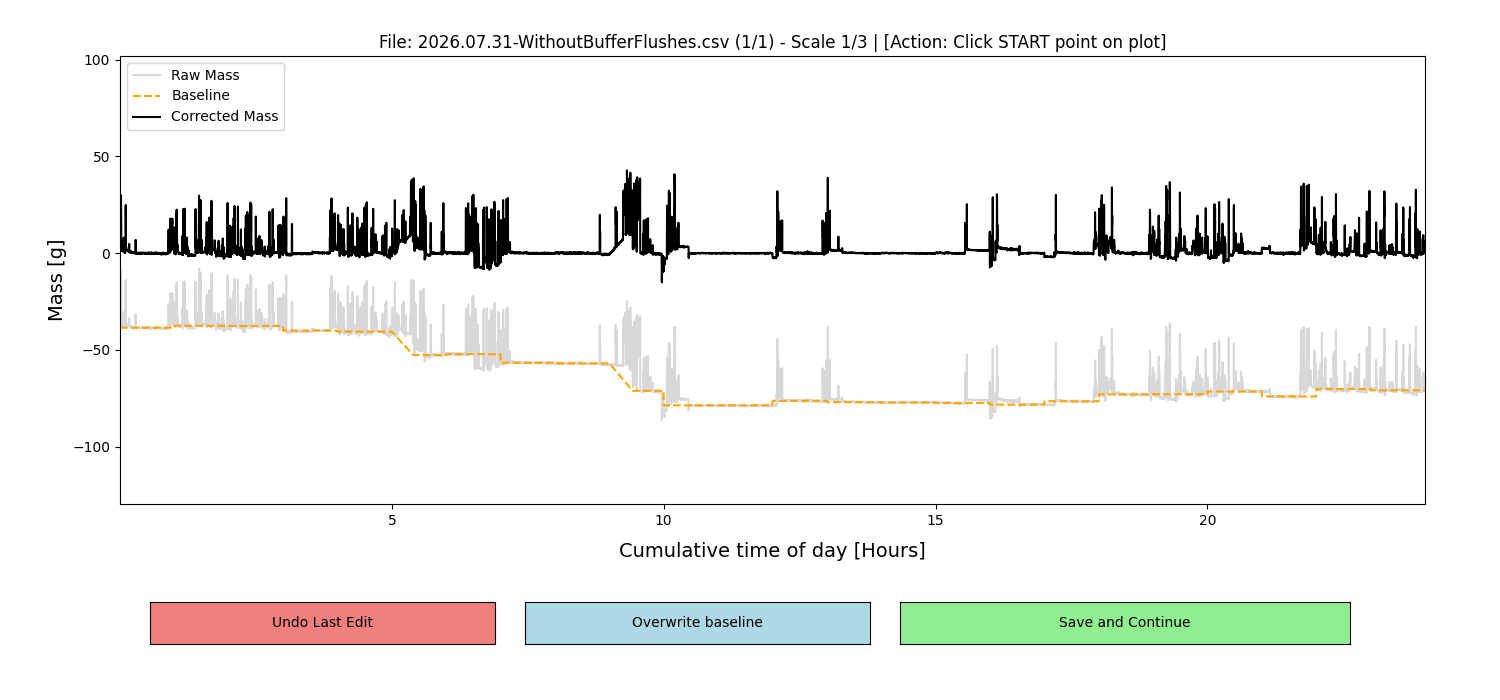

In [ ]:
path = Path(folder_data_of_all_experiment_path)
folder_name = "WithoutBufferFlushes"
if baseline_correction_algorithm != None and outlier_removal:
    folder_name += f"-BaselineCorrectedAndOutlierRemoval-{baseline_correction_algorithm}"
elif baseline_correction_algorithm != None:
    folder_name += f"-BaselineCorrected-{baseline_correction_algorithm}"
elif outlier_removal:
    folder_name += "-OutlierRemovalOnly"
else:
    folder_name += "-Raw"
new_path = path.parent / folder_name
new_path.mkdir(parents=True, exist_ok=True)

# Create temporary local folder for the heavy files, if there is any
create_temporary_local_folder(local_temp_folder=local_temp_folder)

# Access files in folder
files = sorted(os.listdir(folder_data_of_all_experiment_path))

# look at the data per day/file
kept_files = []
for file in files: # removes files/folders that are not mass time series
  if debug_mode:
    print(file)
  if file[-4:] == ".csv":
    kept_files.append(file)
    if debug_mode:
      print("Keeping file : ", file)
  else:
    continue

master_dict = {}
print("Baseline correction algorithm : ", baseline_correction_algorithm)
progress_bar = tqdm(kept_files, bar_format='{l_bar}{bar:30}{r_bar}')


for file in progress_bar:
  progress_bar.set_description(f"Processing: {file}")

  # Get file size in bytes
  drive_path = os.path.join(folder_data_of_all_experiment_path, file)
  file_size = os.path.getsize(drive_path)
  if file_size > file_size_threshold:
    if debug_mode:
      print(f"File size is bigger than {file_size_threshold/ 1e6:.1f} MB. Creating local copy of the files to {local_temp_folder}.")
    local_path = os.path.join(local_temp_folder, file)
    if not os.path.exists(local_path):
      shutil.copy(drive_path, local_path)
    read_path = local_path
  else:
    read_path = folder_data_of_all_experiment_path + file

  df = pd.read_csv(read_path)
  time_array = df.iloc[:, 0].to_numpy()
  time_array_float = time_array.astype(dtype=np.float32)
  time_array_cumulative = get_cumulative_time(time=time_array_float)
  mass_array = df.iloc[:, 1:].to_numpy(dtype=np.float32)

  baselines_for_this_file = []


  # Removing outliers improves the baseline correction accuracy
  if outlier_removal:
    mass_array = remove_outliers(data=mass_array, window_size=sampling_frequency/2)
    if debug_mode:
      print(f"Relative number of np.nan after ONLY outlier removal : {np.isnan(mass_array).sum()/(mass_array.shape[0]*mass_array.shape[1]):.7f}.")

  positions_of_character = file.find("-")
  # Baseline correction
  if baseline_correction_algorithm != None:
    for i in range(mass_array.shape[1]):
      smoothened_mass_data_of_scale_i = smooth_mass_data(time_vector=time_array_cumulative, data_of_scale=mass_array[:,i], window_size="2s")
      if baseline_correction_algorithm == "DBSCAN":
        baseline_of_scale_i = classify_baseline_dbscan(time_vector=time_array_cumulative, data_of_scale=smoothened_mass_data_of_scale_i, bin_size=bin_size, debug_mode=debug_mode, scale_number=i, save_path=new_path, file_name=file[:positions_of_character])
      elif baseline_correction_algorithm == "KDE":
        baseline_of_scale_i = classify_baseline_kde(time_vector=time_array_cumulative, data_of_scale=smoothened_mass_data_of_scale_i, bin_size=bin_size, debug_mode=debug_mode, scale_number=i, save_path=new_path, file_name=file[:positions_of_character])
      elif baseline_correction_algorithm == "GMM":
        baseline_of_scale_i = classify_baseline_gmm(time_vector=time_array_cumulative, data_of_scale=smoothened_mass_data_of_scale_i, bin_size=bin_size, debug_mode=debug_mode, scale_number=i, save_path=new_path, file_name=file[:positions_of_character])
      elif baseline_correction_algorithm == "Rolling Mean":
        baseline_of_scale_i = find_baseline_rolling_mean(time=time_array_cumulative, data_of_scale=smoothened_mass_data_of_scale_i, sampling_frequency=sampling_frequency)

      baselines_for_this_file.append(baseline_of_scale_i)

  master_dict[file] = {'time':time_array, 'mass':mass_array, 'baselines':baselines_for_this_file}
  del df, time_array, mass_array, baselines_for_this_file
  gc.collect()

print("Automated baseline correctionc completed. Launching GUI for manual correction...")

if baseline_correction_algorithm is not None:
  if manual_baseline_correction:
    gui = STUAART_GUI(
        master_dict=master_dict,
        number_of_scales=master_dict[list(master_dict.keys())[0]]['mass'].shape[1],
        export_function=lambda d: export_data(
            dict_mass_data=d,
            baseline_correction_algorithm=baseline_correction_algorithm,
            outlier_removal=outlier_removal,
            bin_size=bin_size,
            debug_mode=debug_mode,
            new_path=new_path,
        )
  )
  else:
    export_data(dict_mass_data=master_dict, baseline_correction_algorithm=baseline_correction_algorithm, outlier_removal=outlier_removal, bin_size=bin_size, new_path=new_path, debug_mode=debug_mode)
else:
  export_data(dict_mass_data=master_dict, baseline_correction_algorithm=baseline_correction_algorithm, outlier_removal=outlier_removal, bin_size=bin_size, new_path=new_path, debug_mode=debug_mode)

# Clean up the local file to prevent filling up Colab's disk storage
if local_path and os.path.exists(local_path):
  os.remove(local_path)